<div>
<a href="https://www.audiolabs-erlangen.de/fau/professor/mueller"><img src="data_layout/PCPT_Teaser.png" width=100% style="float: right;" alt="PCPT Teaser"></a>
</div>

# Unit 8: Training Dynamics

<ul>
    <li><a href='#learn' style="color:#E65100;"><strong>Overview and Learning Objectives</strong></a></li> 
    <li><a href='#intro_dataset_noise' style="color:black;">Example: Supervised Learning on Noisy 2D Point Clouds</a></li>    
    <li><a href='#overfitting' style="color:black;">Overfitting and Generalization</a></li>     
    <li><a href='#background_train_val_test' style="color:#1B5E20;"><strong>Background:</strong> Training, Validation, and Test Sets</a></li>    
    <li><a href='#validation_earlystopping' style="color:black;"> Validation Monitoring and Early Stopping</a></li>     
    <li><a href='#pytorch_state_dict' style="color:black;">Storing and Restoring Models with State Dictionaries</a></li>      
    <li><a href='#pytorch_learning_rate_scheduling' style="color:black;">Learning Rate Scheduling</a></li>    
    <li><a href='#exercise_tiny_model' style="color:#006064;"><strong>Exercise 1:</strong> Find Tiny Network that Fits the Data</a></li>
    <li><a href='#exercise_random_seeds' style="color:#006064;"><strong>Exercise 2:</strong> Random Seends</a></li>
    <li><a href='#exercise_schedulers' style="color:#006064;"><strong>Exercise 3:</strong> Inspect Learning Rate Schedulers</a></li>    
</ul>   

<a id='learn'></a>
<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#E65100;">Overview and Learning Objectives</h2>

<p style="color:#E65100;">
This unit introduces key strategies for training neural networks effectively and robustly. Beyond basic gradient descent, the focus is on practical techniques that improve model generalization, monitor training progress, and manage training dynamics. A special emphasis is placed on understanding validation and learning rate scheduling. Using a simple supervised learning task on noisy 2D point clouds in a three-class setting, we work with a small, manageable example throughout this unit. The learning objectives of this unit are as follows:
</p>

<ul style="color:#E65100;">
<li>Recognize and explain the problem of <strong>overfitting</strong>.</li>    
<li>Understand why splitting data into <strong>train</strong>, <strong>validation</strong>, and <strong>test</strong> sets is essential for effective training and fair evaluation.</li> 
<li>Track <strong>validation loss</strong> to detect early signs of overfitting, and apply <strong>early stopping</strong> to preserve the best-performing model.</li> 
<li>Use <code>model.state_dict()</code> in PyTorch to save and reload model parameters efficiently, ensuring reproducibility and recovery of the best model state.</li>
<li>Interpret <strong>loss</strong> and <strong>accuracy</strong> curves to analyze learning behavior and guide adjustments during training.</li> 
<li>Control training dynamics with <strong>learning rate scheduling</strong> strategies via <code>torch.optim.lr_scheduler</code> (e.g., <code>StepLR</code>).</li> 
</ul>

<p style="color:#E65100;">
The unit includes three hands-on exercises:  
</p>
<ul style="color:#E65100;">
<li><a href="#exercise_tiny_model">Exercise 1</a>: Fit a tiny network to the data.</li>  
<li><a href="#exercise_random_seeds">Exercise 2</a>: Investigate how random seeds influence training outcomes.</li>  
<li><a href="#exercise_schedulers">Exercise 3</a>: Explore learning rate schedulers and their effect on training dynamics.</li>  
</ul>

<p style="color:#E65100;">
Together, these exercises introduce foundational concepts for building practical and reliable training workflows.
</p>
</div>

In [1]:
# --- Standard libraries ---
import copy

# --- Core scientific stack ---
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# --- Custom utilities (Unit 8) ---
from libpcpt.unit08 import (
    generate_checkerboard_dataset,
    plot_decision_boundary,
    plot_loss_and_accuracy,
    plot_boundary_and_loss_lr,
    exercise_tiny_model,
    exercise_random_seeds,
    exercise_schedulers
)

<a id='intro_dataset_noise'></a>  
## Example: Supervised Learning on Noisy 2D Point Clouds

This unit introduces a synthetic 2D classification task designed to highlight common challenges in training and generalization. The dataset is based on a structured checkerboard layout arranged in a 3&times;3 grid, where each cell contains samples from one of three alternating classes. To vary the difficulty of the task, **Gaussian noise** is added to the point coordinates. As the noise level increases, class boundaries become increasingly blurred and eventually indistinguishable. This controlled setup provides an intuitive and flexible testbed for exploring how training dynamics are affected by noise and data complexity. We will use this classification scenario to investigate key training issues:

* How **overfitting** occurs when models memorize noisy data.  
* How **validation performance** can help detect and prevent overfitting. 
* How **early stopping** and **learning rate scheduling** can improve robustness.
  
To keep the focus on training concepts, we use predefined utility functions for **dataset generation** and **visualization**. These abstractions provide consistent inputs and clear visualizations, while hiding implementation details that are not essential at this stage. The plots below show datasets generated at increasing noise levels:

- **Low noise**: Class clusters are tight and clearly separable. 
- **Medium noise**: Class overlap increases, boundaries become less distinct.  
- **High noise**: Class distinctions blur, making accurate classification increasingly difficult.

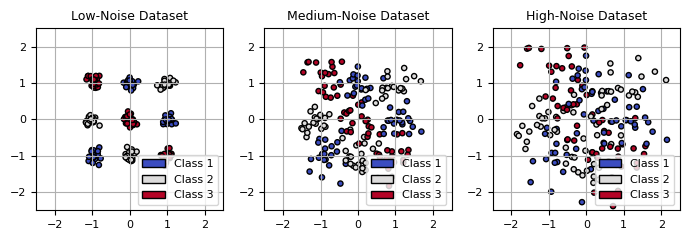

In [2]:
# Generate datasets with increasing noise levels
noise_levels = [0.1, 0.3, 0.5]
datasets = [generate_checkerboard_dataset(n_per_cell=20, noise=noise, seed=0) 
            for noise in noise_levels]
titles = ["Low-Noise Dataset", "Medium-Noise Dataset", "High-Noise Dataset"]

# Plot datasets side by side
fig, axs = plt.subplots(1, 3, figsize=(7, 2.5))
for ax, dataset, title in zip(axs, datasets, titles):
    plot_decision_boundary(dataset, model=None, ax=ax, title=title)

plt.tight_layout()
plt.show()

### Training a Neural Network on Noisy Data

To analyze how neural networks respond to varying data complexity, we now train a simple feedforward model on each of the three datasets introduced earlier. We use a **4-layer multilayer perceptron (MLP)** consisting of three hidden layers with ReLU activations and a final linear layer that maps to three output logits. The input dimensionality is 2 (corresponding to the spatial coordinates of the data points), and the total number of trainable parameters is **483**. The model architecture is deliberately small and fixed, as the focus lies not on architectural optimization, but on **training behavior under noisy conditions**.

Training is performed using **cross-entropy loss**, optimized via the **Adam optimizer** with a fixed learning rate. Mini-batches are used for weight updates. The process is encapsulated in the `train_model` function, which handles forward/backward passes, gradient updates, and periodic reporting of training accuracy. Each model is trained for **20 epochs** on its corresponding dataset. After training, we visualize the resulting **decision boundaries** and report the **overall classification accuracy**. This allows us to assess how well the model adapts to increasing levels of noise. 


Processing dataset: Low-Noise Dataset


Epoch  10/20 | Loss: 0.7559 | Accuracy: 100.00%
Epoch  20/20 | Loss: 0.0130 | Accuracy: 100.00%

Processing dataset: Medium-Noise Dataset
Epoch  10/20 | Loss: 3.2397 | Accuracy: 74.44%
Epoch  20/20 | Loss: 2.2064 | Accuracy: 84.44%

Processing dataset: High-Noise Dataset


Epoch  10/20 | Loss: 4.8366 | Accuracy: 59.44%
Epoch  20/20 | Loss: 4.2484 | Accuracy: 68.89%


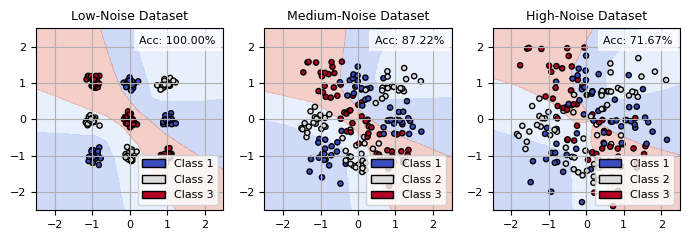

In [3]:
# Define the MLP model
class SimpleMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=16, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, num_classes)
        )  
    def forward(self, x):
        return self.net(x)
        
# Training function with default loss and optimizer
def train_model(model, dataloader, 
                criterion=None, 
                optimizer=None, 
                lr=0.01, 
                n_epochs=200, 
                logging_interval=50):
    """
    Trains a PyTorch model with optional custom loss and optimizer.
    Logs accuracy during training.
    """
    if criterion is None:
        criterion = nn.CrossEntropyLoss()
    if optimizer is None:
        optimizer = optim.Adam(model.parameters(), lr=lr)
        
    model.train()
    for epoch in range(n_epochs):
        total_loss, correct, total = 0.0, 0, 0

        for x_batch, y_batch in dataloader:
            logits = model(x_batch)
            loss = criterion(logits, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

        if (epoch + 1) % logging_interval == 0:
            acc = 100 * correct / total
            print(f"Epoch {epoch+1:3d}/{n_epochs} | "
                  f"Loss: {total_loss:.4f} | Accuracy: {acc:.2f}%")
    return model

# Training and visualization for datasets with increasing noise
models = []
batch_size = 32
hidden_dim = 16
titles = ["Low-Noise Dataset", "Medium-Noise Dataset", "High-Noise Dataset"]

for dataset, title in zip(datasets, titles):
    print(f"\nProcessing dataset: {title}")
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    torch.manual_seed(0)
    model = SimpleMLP(input_dim=2, hidden_dim=hidden_dim, num_classes=3)
    model = train_model(model, dataloader, lr=0.01, n_epochs=20, logging_interval=10)
    models.append(model)

# Plot decision boundaries side-by-side
fig, axs = plt.subplots(1, 3, figsize=(7, 2.5))
for i in range(3):
    plot_decision_boundary(datasets[i], model=models[i], ax=axs[i], title=titles[i])
plt.tight_layout()
plt.show()

<a id='overfitting'></a>  
## Overfitting and Generalization

In machine learning, more training does not always lead to better results. When a model begins to fit not only the underlying structure of the data but also its random fluctuations, it is said to **overfit**. This means the model performs well on the training data but fails to generalize to new, unseen examples. To illustrate this phenomenon, we focus on the most challenging of our dataset, the **high-noise dataset**, where the class boundaries are difficult to detect due to substantial random variation. We train the same model architecture (`SimpleMLP`) for different durations: **50**, **200**, and **500 epochs**, keeping all other parameters fixed. This progression allows us to observe:

* How the model initially learns rough trends from noisy data
* How longer training encourages memorization of noise rather than structure
* How the resulting decision boundaries become increasingly irregular and unstable


Training model for 50 epochs:


Epoch  50/50 | Loss: 3.6963 | Accuracy: 71.67%

Training model for 200 epochs:


Epoch  50/200 | Loss: 3.6963 | Accuracy: 71.67%


Epoch 100/200 | Loss: 3.4732 | Accuracy: 71.11%


Epoch 150/200 | Loss: 3.6123 | Accuracy: 72.22%


...

Epoch 300/500 | Loss: 3.1169 | Accuracy: 76.11%


Epoch 350/500 | Loss: 2.8609 | Accuracy: 78.89%


Epoch 400/500 | Loss: 2.8409 | Accuracy: 78.89%


Epoch 450/500 | Loss: 2.5242 | Accuracy: 81.11%


Epoch 500/500 | Loss: 2.4989 | Accuracy: 80.56%


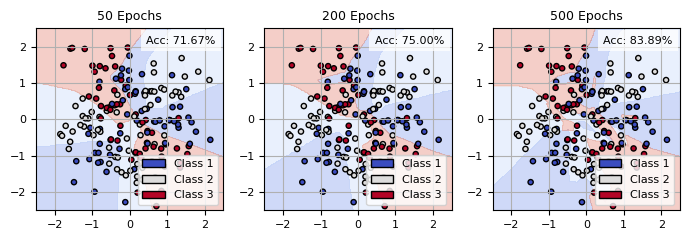

In [4]:
# Select high-noise dataset
dataset = datasets[2]
batch_size = 32
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Training settings
epochs_list = [50, 200, 500]
titles_epoch = [f"{n} Epochs" for n in epochs_list]
models = []

# Train models for different epochs
for n_epochs, title in zip(epochs_list, titles_epoch):
    print(f"\nTraining model for {n_epochs} epochs:")
    torch.manual_seed(0)
    model = SimpleMLP(input_dim=2, hidden_dim=hidden_dim, num_classes=3)
    trained_model = train_model(model, dataloader, lr=0.01, 
                                n_epochs=n_epochs, logging_interval=50)
    models.append(trained_model)

# Plot decision boundaries
fig, axs = plt.subplots(1, len(models), figsize=(7, 2.5))
for ax, model, title in zip(axs, models, titles_epoch):
    plot_decision_boundary(dataset, model=model, ax=ax, title=title)
plt.tight_layout()
plt.show()

### Evaluating Generalization Performance

To examine how overfitting affects generalization, we evaluate the model trained on the **high-noise dataset** using two new test sets. These sets have the same structure and noise level but were generated with **different random seeds**. As shown in the results of the following code cell, the model reaches high accuracy on the training set, yet its performance drops significantly on unseen data:

- **Training Set**: 83.89% accuracy  
- **Test Set 1**: 51.11% accuracy  
- **Test Set 2**: 58.33% accuracy

This sharp drop in performance reflects a classic case of **overfitting**: although the model has learned to replicate patterns in the noisy training set, it struggles to generalize to new data drawn from the same distribution. In essence, it memorizes rather than understands. The visualizations make this evident. Decision boundaries that align well with the training data fail to capture the class structure in the test sets.

This result shows why training should focus on **generalization**, meaning good performance on unseen data. Key practices include using a **validation set**, applying **early stopping**, and adding **regularization**, especially for noisy or ambiguous datasets.

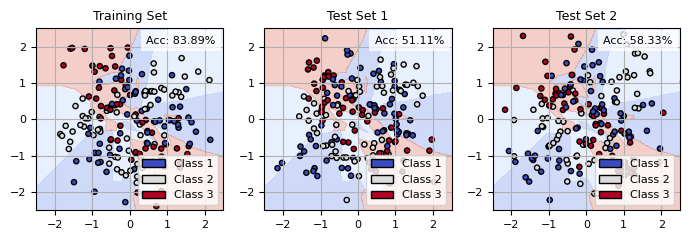

In [5]:
# Generate two test sets with same noise level (0.5) but different random seeds
# Allows us to assess model generalization to new data from the same distribution.
dataset_test_1 = generate_checkerboard_dataset(n_per_cell=20, noise=0.5, seed=1)
dataset_test_2 = generate_checkerboard_dataset(n_per_cell=20, noise=0.5, seed=2)

# Plot the learned decision boundary on the training set and test sets
model = models[2]
fig, axs = plt.subplots(1, 3, figsize=(7, 2.5))
plot_decision_boundary(dataset, model=model, ax=axs[0], title="Training Set")
plot_decision_boundary(dataset_test_1, model=model, ax=axs[1], title="Test Set 1")
plot_decision_boundary(dataset_test_2, model=model, ax=axs[2], title="Test Set 2")
plt.tight_layout()
plt.show()

<a id='background_train_val_test'></a>  
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#1B5E20;">Background: Training, Validation, and Test Sets</h2>

<p style="color:#1B5E20;">
In supervised learning, the objective is not simply to memorize training examples, but to uncover patterns that generalize to new, unseen data. To assess whether a model achieves this, the dataset is typically divided into three distinct subsets:
</p>

<ul style="color:#1B5E20;">
    <li><strong>Training set:</strong> This subset is used to update the model's parameters. It guides the learning process by minimizing the loss for this data. However, strong performance on the training set alone only shows that the model can fit known data, not that it will generalize well to new examples.</li> 
    <li><strong>Validation set:</strong> This separate subset is used during training to evaluate how well the model generalizes. It helps monitor progress, tune hyperparameters, and detect overfitting. Since the model does not directly learn from this data, its performance here serves as a proxy for how well it might handle unseen inputs. For instance, if the training loss decreases but the validation loss increases, overfitting may be occurring.</li> 
    <li><strong>Test set:</strong> The test set is used only after training is complete. It provides an unbiased evaluation of the final model and estimates how well it is likely to perform in real-world conditions. No decisions during training should be based on test set performance.</li> 
</ul>

<p style="color:#1B5E20;">
Separating data in this way is essential for reliable evaluation. Without it, models risk being assessed on the very data they were trained to fit, leading to misleading performance metrics. A model that excels only on its training data may be <strong>overfitting</strong> and may not perform well on new inputs. More broadly, this practice reflects a foundational principle in scientific inquiry: just as a theory should be tested on evidence that was not used to build it, a machine learning model should be judged by how well it performs on data it has never seen.
</p>
</div>

<a id='validation_earlystopping'></a>  
## Validation Monitoring and Early Stopping

To detect overfitting during training, it is essential to monitor model performance not only on the training set, but also on a separate **validation set**. This validation set is not used to update the model's parameters and therefore provides a more realistic estimate of how well the model might perform on unseen data.

* **Validation monitoring** involves evaluating the model after each epoch (or at regular intervals) on this held-out data. If training accuracy keeps increasing while validation accuracy plateaus or drops, this is a strong indication that the model is beginning to overfit.

* **Early stopping** builds directly on this idea. Instead of training for a fixed number of epochs, training is automatically stopped when no improvement is seen on the validation set for a given number of steps (the **patience** parameter). At that point, the model is typically restored to the version that achieved the best validation performance.

Together, these techniques improve generalization, reduce overfitting, and help avoid unnecessary training time. They are particularly effective when dealing with noisy or limited data, as illustrated by our high-noise classification example. The following code demonstrates how to implement these methods in PyTorch, while also returning the full training and validation curves for later visualization. The training function also includes a learning rate scheduler, which we will discuss later in this unit.

In [6]:
# -------------------------------
# Extended training function with early stopping and optional scheduler
# -------------------------------
def train_model_extended(model, 
                dataloader, 
                val_dataloader=None, 
                criterion=None, 
                optimizer=None, 
                scheduler=None, 
                lr=0.01, 
                n_epochs=200, 
                logging_interval=50, 
                patience=None):
    """
    Trains a PyTorch model with optional validation, early stopping, and LR scheduling.

    Returns:
        model: Trained model (restored to best validation state if applicable)
        train_loss: List of training losses per epoch
        train_acc: List of training accuracies per epoch
        val_loss: List of validation losses per epoch (if val_dataloader is provided)
        val_acc: List of validation accuracies per epoch (if val_dataloader is provided)
        best_epoch: Epoch number (starting from 1) at which validation loss was lowest
        lr_history: List of learning rates per epoch
    """
    if criterion is None:
        criterion = nn.CrossEntropyLoss()
    if optimizer is None:
        optimizer = optim.Adam(model.parameters(), lr=lr)

    best_model_state = None
    best_val_loss = float('inf')
    best_epoch = 0
    epochs_no_improve = 0

    train_loss, train_acc = [], []
    val_loss, val_acc = [], []
    lr_history = []

    for epoch in range(n_epochs):
        # --- Training ---
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for x_batch, y_batch in dataloader:
            logits = model(x_batch)
            loss = criterion(logits, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

        train_loss.append(total_loss)
        train_acc.append(100 * correct / total)

        # --- Validation ---
        if val_dataloader is not None:
            model.eval()
            v_total_loss, v_correct, v_total = 0.0, 0, 0
            with torch.no_grad():
                for x_val, y_val in val_dataloader:
                    logits = model(x_val)
                    loss = criterion(logits, y_val)
                    v_total_loss += loss.item()
                    preds = torch.argmax(logits, dim=1)
                    v_correct += (preds == y_val).sum().item()
                    v_total += y_val.size(0)
            val_loss.append(v_total_loss)
            val_acc.append(100 * v_correct / v_total)

        # --- Scheduler step ---
        if scheduler is not None:
            # Do not use ReduceLROnPlateau here (needs a metric)
            scheduler.step()

        # Record learning rate at end of epoch
        current_lr = optimizer.param_groups[0]['lr']
        lr_history.append(current_lr)

        # --- Logging ---
        if logging_interval is not None:
            if (epoch + 1) % logging_interval == 0 or epoch == 0:
                logging = f"Ep {epoch+1:3d}/{n_epochs} | T-L: {total_loss:6.4f} | "
                logging += f"T-A: {train_acc[-1]:5.2f}% | LR: {current_lr:.5g}"
                if val_dataloader:
                    logging += f" | V-L: {v_total_loss:6.4f} | V-A: {val_acc[-1]:5.2f}%"
                print(logging)

        # --- Early stopping ---
        if val_dataloader and patience is not None:
            if v_total_loss < best_val_loss:
                best_val_loss = v_total_loss
                # Save parameters of best model so far (via state_dict)
                best_model_state = copy.deepcopy(model.state_dict())
                best_epoch = epoch + 1
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    if logging_interval is not None:
                        print(f"Early stopping triggered at epoch {epoch+1}.")
                    if best_model_state:
                         # Load the saved parameters of the best validation model
                        model.load_state_dict(best_model_state)
                    break

    return model, train_loss, train_acc, val_loss, val_acc, best_epoch, lr_history

Ep   1/500 | T-L: 6.6633 | T-A: 33.89% | LR: 0.01 | V-L: 6.5684 | V-A: 40.00%
Ep  10/500 | T-L: 4.7466 | T-A: 58.89% | LR: 0.01 | V-L: 6.0109 | V-A: 50.56%
Ep  20/500 | T-L: 4.2570 | T-A: 65.00% | LR: 0.01 | V-L: 5.9405 | V-A: 55.56%


Ep  30/500 | T-L: 4.2679 | T-A: 71.67% | LR: 0.01 | V-L: 6.1368 | V-A: 58.33%
Early stopping triggered at epoch 33.


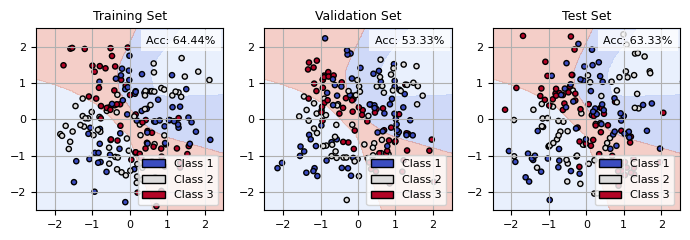

In [7]:
# Generate three sets from same distribution but with different seeds
dataset_train = generate_checkerboard_dataset(n_per_cell=20, noise=0.5, seed=0)
dataset_val   = generate_checkerboard_dataset(n_per_cell=20, noise=0.5, seed=1)
dataset_test  = generate_checkerboard_dataset(n_per_cell=20, noise=0.5, seed=2)

# Dataloaders
batch_size = 32
train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(dataset_val,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(dataset_test,  batch_size=batch_size, shuffle=False)

# Model setup
torch.manual_seed(0)
model = SimpleMLP(input_dim=2, hidden_dim=16, num_classes=3)

# Training with validation monitoring and early stopping
(model, train_loss, train_acc, val_loss, val_acc, 
 best_epoch, lr_history) = train_model_extended(
    model=model,
    dataloader=train_loader,
    val_dataloader=val_loader,
    lr=0.01,
    n_epochs=500,
    logging_interval=10,
    patience=20
)

# Plot decision boundaries
fig, axs = plt.subplots(1, 3, figsize=(7, 2.5))
plot_decision_boundary(dataset_train, model=model, ax=axs[0], title="Training Set")
plot_decision_boundary(dataset_val,   model=model, ax=axs[1], title="Validation Set")
plot_decision_boundary(dataset_test,  model=model, ax=axs[2], title="Test Set")
plt.tight_layout()
plt.show()

### Summary of Results and Model Selection

In our high-noise classification scenario, the previous model trained for 500 epochs showed clear signs of **overfitting**: it achieved **83.89% training accuracy**, but generalization suffered, with test accuracies dropping to **51.11%** and **58.33%** on two independent test sets. This indicates that the model had memorized noisy patterns instead of learning robust structures. After introducing **validation monitoring** and **early stopping**, the retrained model achieves a more balanced outcome:

- **Training Accuracy**: 64.44%  
- **Validation Accuracy**: 53.33%  
- **Test Accuracy**: 63.33%

These results reflect **better generalization**. The test accuracy now closely matches the training accuracy, suggesting that the model has learned features that generalize well to unseen data. The slightly lower validation accuracy may result from the specific random sampling used to generate the validation set, which could have produced a somewhat more complex or ambiguous configuration. This highlights the value of a validation set as a challenging and realistic proxy for assessing model generalization during training. However, these metrics should not be overinterpreted. Due to the randomized nature of training, small changes such as choosing a different random seed can lead to substantially different models and outcomes, see also <a href='#exercise_random_seeds' style="color:#006064;"><strong>Exercise 2</strong></a>.

<a id='monitoring'></a>  
### Monitoring Training Progress with Loss and Accuracy Curves

Monitoring how loss and accuracy change during training is a key method for understanding model behavior and guiding improvements. By visualizing these metrics for both the training and validation sets across epochs, we can detect common issues such as underfitting, overfitting, or unstable learning. These plots help us answer practical questions like: Is the model still learning? Is it starting to memorize the training data? How well does it generalize to unseen inputs?

The code below continues the early stopping example from above. It produces two plots: one showing the loss values and one showing the accuracy scores over time. Each plot includes both training and validation curves, along with a vertical line indicating the epoch with the lowest validation loss. This point was selected by early stopping. These visualizations provide a clear and compact summary of the training process and support informed decisions about model selection, tuning, and evaluation.

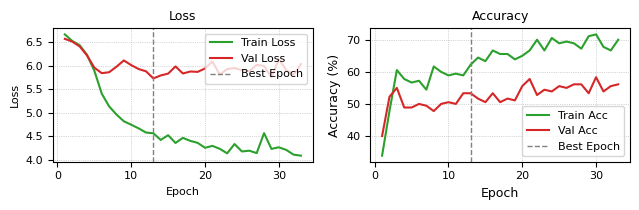

In [8]:
plot_loss_and_accuracy(train_loss, val_loss, train_acc, val_acc, best_epoch)

For larger projects or more advanced workflows, monitoring is typically integrated directly into the training loop. While the static plots above are useful for small-scale experiments and teaching, PyTorch also supports dynamic logging with **TensorBoard** via <code>torch.utils.tensorboard.SummaryWriter</code>. TensorBoard allows you to record metrics such as loss, accuracy, and learning rate, and view them in an interactive browser-based dashboard. It is lightweight, locally hosted, and works with any custom training loop—making it a great tool for both prototyping and reproducible experiments. Applying TensorBoard in practice goes beyond the scope of this course, but it is a valuable next step. For details, see the official [PyTorch guide](https://pytorch.org/tutorials/intermediate/tensorboard_tutorial.html).

<a id='pytorch_state_dict'></a>
## Storing and Restoring Models with State Dictionaries

In the context of early stopping, we preserved the model state that achieved the best validation performance during training. This allowed us to later restore the version that generalized best, rather than relying on the final model, which might be overfitted. PyTorch provides a simple and effective way to do this using its <code>state_dict()</code> functionality.

Every PyTorch model is an instance of <code>nn.Module</code>, and all learnable parameters (such as weights and biases) are stored in a dictionary accessible via <code>model.state_dict()</code>. This dictionary maps parameter names to their corresponding tensors and includes only the model parameters, not training metadata like the optimizer state or current epoch. In our example, we applied this mechanism as follows:

* **Storing:** At each epoch, we monitored validation performance. When an improvement was observed, we saved a snapshot of the current model parameters using <code>best_model_state = copy.deepcopy(model.state_dict())</code>. The deep copy is essential; without it, we would only store a reference to the parameters, which would continue to update during training in subsequent epochs.

* **Restoring:** At the end of training, we reloaded the best-performing parameters using <code>model.load_state_dict(best_model_state)</code>. This ensured that evaluation and deployment were based on the version of the model that generalized best.

Using <code>state_dict()</code> in this way is a standard and efficient practice in PyTorch. It allows for reliable saving and restoring of model parameters, supports reproducible experiments, and ensures that evaluation is based on the best-performing version of the model. The following code cells show what <code>state_dict()</code> contains for the model used in the classification example above.

In [9]:
# Print parameter names and tensor shapes from the state_dict
for param_name, param_tensor in model.state_dict().items():
    print(f"{param_name}: {param_tensor.shape}")

net.0.weight: torch.Size([16, 2])
net.0.bias: torch.Size([16])
net.2.weight: torch.Size([16, 16])
net.2.bias: torch.Size([16])
net.4.weight: torch.Size([8, 16])
net.4.bias: torch.Size([8])
net.6.weight: torch.Size([3, 8])
net.6.bias: torch.Size([3])


<a id='pytorch_learning_rate_scheduling'></a>  
## Learning Rate Scheduling

So far, we have learned how to monitor training and validation performance, restore the best model, and use early stopping to prevent overfitting. Another important concept is the **learning rate**, which is the step size used when updating model parameters during training. If the learning rate is too high, training can become unstable or even diverge. If it is too low, learning slows down and the model might get stuck in a poor solution. In many cases, a good choice for the learning rate depends on the stage of training:

- **Early training** benefits from larger steps to explore the parameter space quickly.  
- **Later training** often works better with smaller steps for fine-tuning.

By adjusting the learning rate during training, a process called **learning rate scheduling**, we can speed up convergence, improve stability, and often achieve better results.

PyTorch provides **learning rate schedulers** in `torch.optim.lr_scheduler` that automatically adjust the learning rate during training. Schedulers can follow a **fixed schedule** (for example, reduce the rate after a specific number of epochs) or adapt based on **training progress** (for example, lower it when validation loss stops improving). A simple example of the fixed type is `StepLR(optimizer, step_size, gamma)`, where:  

- `optimizer`: the optimizer whose learning rate will be updated  
- `step_size`: the number of epochs between each learning rate decay  
- `gamma`: the multiplicative factor used to reduce the learning rate  

In the example below, we train a noisy 2D classification task starting with `optimizer = Adam` at `lr = 0.10` and use `StepLR` to multiply the learning rate by `gamma=0.7` every `step_size=25` epochs. We skip a validation set to focus on the mechanics of scheduling and then plot the training loss together with the learning rate (on a log scale) to visualize how it changes over time. 

Ep   1/200 | T-L: 20.3090 | T-A: 51.94% | LR: 0.1


Ep  25/200 | T-L: 10.6104 | T-A: 82.50% | LR: 0.07


Ep  50/200 | T-L: 8.8696 | T-A: 86.11% | LR: 0.049


Ep  75/200 | T-L: 8.3115 | T-A: 87.22% | LR: 0.0343


Ep 100/200 | T-L: 6.9336 | T-A: 89.31% | LR: 0.02401


Ep 125/200 | T-L: 6.6150 | T-A: 89.58% | LR: 0.016807


Ep 150/200 | T-L: 7.1327 | T-A: 88.75% | LR: 0.011765


Ep 175/200 | T-L: 6.1093 | T-A: 90.14% | LR: 0.0082354


Ep 200/200 | T-L: 6.1407 | T-A: 89.72% | LR: 0.0057648


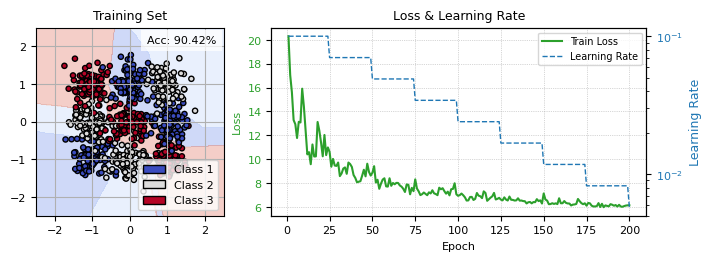

In [10]:
# Prepare training data
dataset_train = generate_checkerboard_dataset(n_per_cell=80, noise=0.28, seed=0)
batch_size = 32
train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

# Model and optimization setup
torch.manual_seed(0)
model = SimpleMLP(input_dim=2, hidden_dim=16, num_classes=3)

lr_init = 0.10
optimizer = torch.optim.Adam(model.parameters(), lr=lr_init)

# Scheduler: reduce LR by 30% every 25 epochs (i.e., multiply by 0.7)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=25, gamma=0.7)

# Train (no validation set here; early stopping is inactive)
model, train_loss, train_acc, val_loss, val_acc, best_epoch, lr_history = train_model_extended(
    model=model,
    dataloader=train_loader,
    val_dataloader=None,
    optimizer=optimizer,
    scheduler=scheduler,
    n_epochs=200,
    logging_interval=25
)

plot_boundary_and_loss_lr(dataset_train, model, train_loss, lr_history)

The plot shows the training loss alongside the learning rate over epochs.  Notice how the loss drops shortly after the learning rate decreases at epochs **25**, **50**, and **100**. This can happen because smaller step sizes make updates more stable and can reduce oscillations. Still, such patterns should be interpreted with caution. Drops may also be caused by random mini-batch sampling or noise in the data. Learning rate scheduling remains a useful tool for guiding training, but results should be confirmed through multiple runs. For further details, see the [PyTorch Learning Rate Scheduling documentation](https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate).

### Implementation Details for Learning Rate Scheduling

In the function `train_model_extended`, the learning rate schedule is controlled by calling `scheduler.step()`. This advances the scheduler's internal counter (epoch or step), moves the schedule forward, and updates the learning rate (LR) stored in the optimizer's `param_groups` according to the chosen scheduling policy.  The updated LR is what the optimizer will use the next time it updates model parameters. The typical sequence of events is as follows:  

* Start with the optimizer's initial LR.  
* Call `scheduler.step()` to advance the schedule and update the LR.  
* Check `optimizer.param_groups[0]['lr']` to see the new LR.  
* In a real training loop, `optimizer.step()` then applies this LR to update the model parameters.  

This process is illustrated in the next code cell.

In [11]:
# Dummy model (1 parameter just to make optimizer valid)
model = torch.nn.Linear(1, 1)

# Optimizer with initial learning rate 0.1
optimizer = optim.SGD(model.parameters(), lr=0.1)

# Scheduler: halve the LR every step_size=1 epoch
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.5)

print(f"Initial LR:    LR = {optimizer.param_groups[0]['lr']}")

# Simulate 5 "epochs" of scheduler stepping
for epoch in range(1, 6):
    optimizer.step()        # no grads needed for this demo
    scheduler.step()        # advance schedule for next step
    print(f"After epoch {epoch:}: LR = {optimizer.param_groups[0]['lr']}")

Initial LR:    LR = 0.1
After epoch 1: LR = 0.05
After epoch 2: LR = 0.025
After epoch 3: LR = 0.0125
After epoch 4: LR = 0.00625
After epoch 5: LR = 0.003125


<a id="exercise_tiny_model"></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064;">Exercise 1: Find Tiny Network that Fits the Data</strong><br>

<p style="color:#006064;">
Using the provided low-noise checkerboard dataset (<code>n_per_cell=20</code>, <code>noise=0.1</code>, <code>seed=0</code>), design an MLP that is as small as possible (fewest trainable parameters) while still achieving <code>100%</code> training accuracy. You are free to explore different network architectures and training procedures. Once you find a model that reaches <code>100%</code>, report the <strong>total number of trainable parameters</strong> and plot the <strong>decision boundary</strong> of your final (smallest) model. Make your result reproducible by fixing all necessary seeds. The tiniest model with perfect accuracy gets the glory&mdash;and maybe a trophy <span role="img" aria-label="trophy">🏆</span> from the instructor.
</p>
</div>

In [12]:
# dataset = generate_checkerboard_dataset(n_per_cell=20, noise=0.1, seed=0)
# Your Solution

Layer (type:depth-idx)                   Output Shape              Param #
TinyMLP                                  [16, 3]                   --
├─Sequential: 1-1                        [16, 3]                   --
│    └─Linear: 2-1                       [16, 5]                   15
│    └─ReLU: 2-2                         [16, 5]                   --
│    └─Linear: 2-3                       [16, 3]                   18
Total params: 33
Trainable params: 33
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

Trainable parameters: 33
Note: There are better solutions with fewer number of parameters!!!
Epoch   1/50 | Train Loss: 13.6106 | Train Acc:  33.33% | LR: 0.01
Epoch  10/50 | Train Loss: 10.6261 | Train Acc:  55.56% | LR: 0.01
Epoch  20/50 | Train Loss:  6.7651 | Train Acc:  70.56% | LR: 0.01


Epoch  30/50 | Train Loss:  4.5263 | Train Acc:  88.89% | LR: 0.01
Epoch  40/50 | Train Loss:  3.3970 | Train Acc: 100.00% | LR: 0.01
Epoch  50/50 | Train Loss:  2.6591 | Train Acc: 100.00% | LR: 0.01


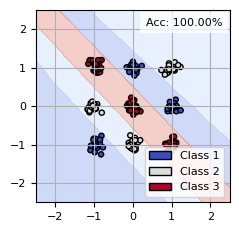

In [13]:
# Run and show output of the reference solution
exercise_tiny_model()

<a id='exercise_random_seeds'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064;">Exercise 2: Effect of Random Seeds</strong><br>

<p style="color:#006064;">
Training a neural network depends on several random factors, such as how the model weights are initialized and the order in which training samples are presented. Even with the same data and hyperparameters, simply changing the random seed can lead to noticeably different results.
</p>

<p style="color:#006064;">
Using the same setup and function from the section <strong>"Validation Monitoring and Early Stopping"</strong>, change the <code>seed</code> in <code>torch.manual_seed(seed)</code> before creating the model with <code>model = SimpleMLP(input_dim=2, hidden_dim=16, num_classes=3)</code>.  Try different seed values (for example, <code>[0, 3, 18]</code>) and:
</p>

<ul style="color:#006064;">
<li>Train the model with the same dataset splits and hyperparameters.</li>
<li>Record the training, validation, and test accuracies.</li>
<li>Plot the decision boundaries for all three sets.</li>
<li>Compare the results across seeds.</li>
</ul>

<p style="color:#006064;">
Reflect on:
</p>
<ul style="color:#006064;">
<li>Do the accuracies change significantly?</li>
<li>How different are the decision boundaries?</li>
<li>Why do these differences occur, and how are they related to weight initialization and mini-batch shuffling?</li>
<li>What strategies could make results more reliable (e.g., multiple runs, averaging, ensembles)?</li>
</ul>
</div>

In [14]:
# Your Solution

Seed 0: Best Epoch=13, TL=4.5647, TA=62.22%, VL=5.7290, VA=53.33%, TestL=4.9002, TestA=63.33%


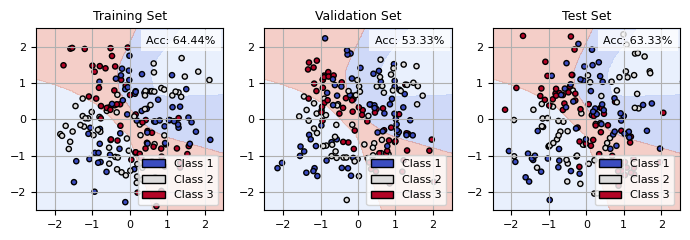

Seed 3: Best Epoch=27, TL=4.1843, TA=69.44%, VL=5.8092, VA=57.78%, TestL=4.7724, TestA=66.67%


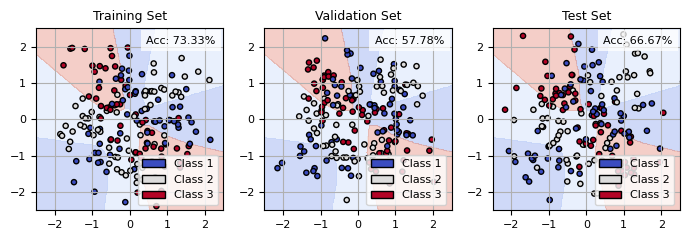

Seed 18: Best Epoch=9, TL=4.9902, TA=59.44%, VL=5.6355, VA=48.89%, TestL=4.9570, TestA=58.33%


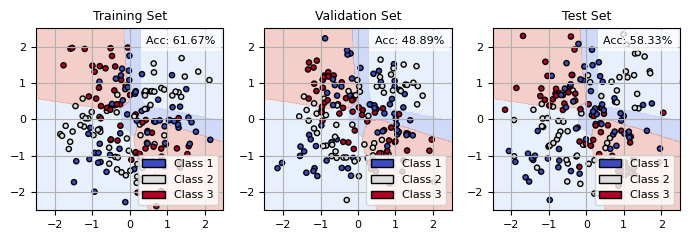

In [15]:
# Run and show output of the reference solution
exercise_random_seeds()

<a id='exercise_schedulers'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064;">Exercise 3: Inspect Learning Rate Schedulers</strong><br>

<p style="color:#006064;">
In this exercise, you will explore several popular PyTorch learning rate schedulers to see how they evolve over epochs <strong>without</strong> running any training loops. You do <strong>not</strong> need real data, a forward pass, or a backward pass. Simply create a <strong>dummy</strong> model and optimizer so that the schedulers have something to control. Use <code>scheduler.step()</code> to advance the schedule and <code>optimizer.param_groups[0]['lr']</code> to read the current learning rate (LR).  
</p>

<ul style="color:#006064;">
    <li>Generate LR histories for different scheduler types and configurations (just use a small number of epochs, e.g., <code>30</code>).</li>
    <li>Visualize how the learning rate evolves over epochs without actual training.</li>
    <li>Examine and compare the behavior of each scheduler.</li>
    <li>Understand the role of key parameters.</li>
    <li>Experiment with different parameter settings for each scheduler.</li>
</ul>

<p style="color:#006064;">
Consider investigating among others the following schedulers provided by PyTorch:
</p>
<ul style="color:#006064;">
    <li><code>StepLR</code>: Discrete drops in LR at fixed intervals.</li>
    <li><code>CosineAnnealingLR</code>: Smooth decay to a minimum LR.</li>
    <li><code>CosineAnnealingWarmRestarts</code>: Smooth decay with periodic restarts.</li>
    <li><code>OneCycleLR</code>: Increases then decreases LR in a single training cycle.</li>
</ul>

<p style="color:#006064;">
Try adjusting parameters such as <code>step_size</code>, <code>gamma</code>, <code>T_max</code>, <code>T_0</code>, <code>T_mult</code>, <code>max_lr</code>, and <code>pct_start</code> to see how the LR curves respond.
</p>
</div>

In [16]:
# Your Solution

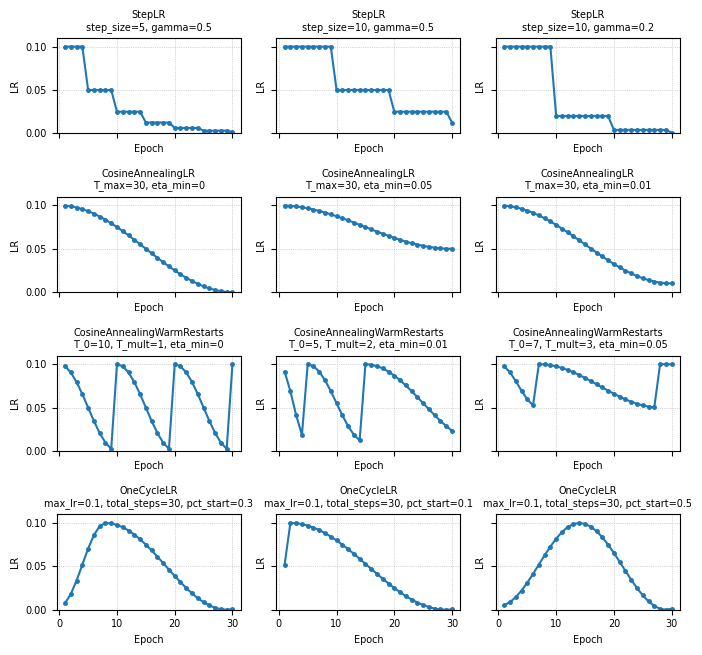

In [17]:
# Run and show output of the reference solution
exercise_schedulers()

<div>
<a href="https://opensource.org/licenses/MIT"><img src="data_layout/PCPT_License.png" width=100% style="float: right;" alt="PCPT License"></a>
</div>